# Projet OPTICAL : Estimation du flot optique (Florian LUCE)

# Cas idéal

Soit $\Omega \subset \mathbb{R}^2$ l'ensemble des pixels d'une image. Soit $\dot{u} : \Omega \to \mathbb{R}, \dot{v} : \Omega \to \mathbb{R}$ deux fonctions qui associent chaque pixel $(x,y)$ d'une image à un pixel $(x + \dot{u}(x,y), y + \dot{v}(x,y))$ de l'image suivante. 

Soit $\dot{I} : \Omega \times \mathbb{R} \to \mathbb{R} $ l'intensité lumineuse au pixel $(x,y)$ à l'instant $t$. On suppose que $\dot{I} \in \mathcal{C}^1$ et soit $\varepsilon \gt 0$. 

On fait un développpement limité de Taylor à l'ordre 1 de $\dot{I}(x+\varepsilon \dot{u}(x,y), y+\varepsilon \dot{v}(x,y), t+ \varepsilon)$ au point $(x,y,t)$ :

\begin{align*} 
\dot{I}(x+ \varepsilon \dot{u}(x,y), y+ \varepsilon \dot{v}(x,y), t+\varepsilon) &= \dot{I}((x,y,t) +  \varepsilon \cdot ( \dot{u}(x,y), \dot{v}(x,y),1)) \\
&= \dot{I}(x,y,t) + <\nabla \dot{I}(x,y,t),\varepsilon \cdot (\dot{u}(x,y),\dot{v}(x,y),1)> + o(||\varepsilon \cdot (\dot{u}(x,y),\dot{v}(x,y),1)||_2) \\
&= \dot{I}(x,y,t) + \varepsilon \cdot ( \frac{\partial \dot{I}(x,y,t) }{\partial x} \cdot  \dot{u}(x,y)+ \frac{\partial \dot{I}(x,y,t) }{\partial y}\cdot \dot{v}(x,y) + \frac{\partial \dot{I}(x,y,t) }{\partial t}\cdot  1 ) + o(\varepsilon) 
\end{align*}

avec $o(||\varepsilon \cdot (\dot{u}(x,y),\dot{v}(x,y),1)||_2) = o(\varepsilon)$ car $(\dot{u}(x,y),\dot{v}(x,y),1)$ est constant car $(x,y)$ est fixé.

On pose $\dot{u} = \dot{u}(x,y)$ et $\dot{v} = \dot{v}(x,y)$ puis $\dot{I}_x = \frac{\partial I(x,y,t) }{\partial x}$, $\dot{I}_y = \frac{\partial \dot{I}(x,y,t) }{\partial y}$ et $\dot{I}_t = \frac{\partial I(x,y,t) }{\partial t}$.

En utilisant l'hypothèse de constance de l'intensité, c'est-à-dire $\dot{I}(x+\varepsilon \dot{u}, y+ \varepsilon \dot{v}, t+\varepsilon) = \dot{I}(x,y,t)$, en divisant par $\varepsilon$ puis en faisant tendre $\varepsilon$ vers $0$, on aboutit à l'équation du flot optique :

$$\dot{I}_x\cdot \dot{u} + \dot{I}_y\cdot \dot{v} + \dot{I}_t = 0$$

Cette équation admet une infinité de solutions car nous avons deux inconnues $(\dot{u},\dot{v})$ pour une seule contrainte d'égalité. Or un même pixel ne peut pas être à deux endroits en même temps après un déplacement. Il est donc nécessaire d'ajouter des contraintes suplémentaires.

La méthode Horn-Schunck permet d'ajouter une contrainte de régularisation spatiale pour imposer que le champ de flot $(\dot{u},\dot{v})$ varie lentement dans l'espace. Cela signifie que les vecteurs de déplacement de pixels voisins doivent être similaires.

## Fonction d'énergie

Cette méthode s'exprime par la minimisation d'une fonction d'énergie : 

$$\boxed{\dot{E}(\dot{u},\dot{v}) = {\int \int}_\Omega [(\dot{I}_x\dot{u} + \dot{I}_y\dot{v} + \dot{I}_t)^2 + \alpha (||\nabla \dot{u}||_2^2 + ||\nabla \dot{v}||_2^2)] \,dx\, dy}$$

- $(\dot{I}_x\dot{u} + \dot{I}_y\dot{v} + \dot{I}_t)^2$ mesure l'erreur par rapport à  l'équation du flot optique causée par la variation temporelle $\dot{I}_t$ non compensée par le mouvement $(\dot{u},\dot{v})$. La minimisation de $E$ force ce terme à être proche de zéro.

- $\alpha (||\nabla \dot{u}||_2^2 + ||\nabla \dot{v}||_2^2)$ contrôle la régularité spatiale de $\dot{u}$ et de $\dot{v}$. $||\nabla \dot{u}||_2$ et  $||\nabla \dot{v}||_2$ représente respectivement l'amplitude des variations de $\dot{u}$, et de $\dot{v}$, plus ces valeurs sont élevées, plus cela indique une variation abrupte de ces fonctions. Plus $||\nabla \dot{u}||_2$ et  $||\nabla \dot{v}||_2$ sont petits, plus $\dot{u}$ et $\dot{v}$ sont réguliers, c'est-à-dire que le déplacement en fonction du temps est continue.

- $\alpha \gt 0$ est le paramètre de régularisation spatiale qui fait le compromis entre la fidélité des données et la régularité de $\dot{u}$ et $\dot{v}$.
Plus $\alpha$ est grand, plus on impose que $\dot{u}$ et $\dot{v}$ varient lentement dans l'espace.
Plus $\alpha$ est petit, moins $(||\nabla \dot{u}||_2^2 + ||\nabla \dot{v}||_2^2)$ aura d'influence par rapport à $(\dot{I}_x\dot{u} + \dot{I}_y\dot{v} + \dot{I}_t)^2$
sur la minimisation de $E$.

## Equations d'Euler-Lagrange

Puisque $\dot{E}$ prend en entrée deux fonctions, il s'agit d'une fonctionnelle, considérons alors le lagrangien $\mathcal{L}$ tel que :

$$\dot{E}(\dot{u},\dot{v}) = {\int \int}_\Omega \mathcal{L}(x,y,t,\dot{u},\dot{v},\nabla \dot{u}, \nabla \dot{v}) \,dx\, dy$$

Si $(\dot{u},\dot{v})$ est un point stationnaire de $E$, en supposant que $\dot{u}$ et $\dot{v}$ sont de classe $\mathcal{C}^2(\Omega)$, soit la condition nécessaire d'Euler (analogue à la condition nécessaire de d'optimalité du premier ordre) nous dit que : $${\frac{\mathrm{d} E(\dot{u} +\varepsilon h, \dot{v} + \varepsilon h)}{\mathrm{d}\varepsilon}}_{|\varepsilon =0} $$

pour toutes fonctions $h, k : \Omega \to \mathbb{R}$ de classe $\mathcal{C}^2(\Omega)$ nulles sur $\partial \Omega$. Or on a également :



$$\frac{\mathrm{d} E(\dot{u} +\varepsilon h, \dot{v} + \varepsilon k)}{\mathrm{d}\varepsilon  }_{|\varepsilon =0} = \iint_{\Omega} \left[ \left\langle \frac{\partial \mathcal{L}}{\partial \dot{u}}, h \right\rangle + \left\langle \frac{\partial \mathcal{L}}{\partial \dot{v}}, k \right\rangle + \left\langle \frac{\partial \mathcal{L}}{\partial (\nabla \dot{u})}, \nabla h \right\rangle + \left\langle \frac{\partial \mathcal{L}}{\partial (\nabla \dot{v})}, \nabla k \right\rangle \right] dx\,dy$$

où $ \left\langle \cdot , \cdot \right\rangle $ est le produit scalaire euclidien sur $\mathbb{R}^2$. Par une intégration par partie d'un des termes, en primitivant $\nabla h$ et en dérivant $\frac{\partial \mathcal{L}}{\partial (\nabla \dot{u})}$ :

$$
\iint_{\Omega}  \left\langle \frac{\partial \mathcal{L}}{\partial (\nabla \dot{u})}, \nabla h \right\rangle dx\,dy = 
\oint_{\partial \Omega} \left\langle \frac{\partial \mathcal{L}}{\partial (\nabla \dot{u})}, hn  \right\rangle d \sigma  - 
\iint_{\Omega} \left\langle \nabla \cdot \frac{\partial \mathcal{L}}{\partial (\nabla \dot{u})} ,  h \right\rangle dx\,dy
$$

où $n$ est un vecteur unitaire normal à $\partial \Omega $. Comme $h$ est nulle au bord, on ne s'occupe que du deuxième terme. En faisant de même avec le terme implicant $\nabla k$, la condition d'Euler devient : 

$$
\iint_{\Omega}
\left[
\left\langle
\frac{\partial \mathcal{L}}{\partial \dot{u}} - \nabla \cdot \frac{\partial \mathcal{L}}{\partial (\nabla \dot{u})}
,
h
\right\rangle
+
\left\langle
\frac{\partial \mathcal{L}}{\partial \dot{v}} - \nabla \cdot \frac{\partial \mathcal{L}}{\partial (\nabla \dot{v})} 
,
k
\right\rangle    
\right] 
dx\, dy = 0
$$

Le lemme fondammental du calcul des variations (cas vectoriel avec intégrale multiple) implique :

$$
\frac{\partial \mathcal{L}}{\partial \dot{u}} - \nabla \cdot \frac{\partial \mathcal{L}}{\partial (\nabla \dot{u})} = 0
\qquad \textbf{et} \qquad
\frac{\partial \mathcal{L}}{\partial \dot{v}} - \nabla \cdot \frac{\partial \mathcal{L}}{\partial (\nabla \dot{v})} = 0
$$

Or, comme : 

$$
\frac{\partial \mathcal{L}}{\partial \dot{u}} = 2\dot{I_x}(\dot{I}_x\cdot \dot{u} + \dot{I}_y\cdot \dot{v} + \dot{I}_t)
$$
$$
\frac{\partial \mathcal{L}}{\partial \dot{v}} = 2\dot{I_y}(\dot{I}_x\cdot \dot{u} + \dot{I}_y\cdot \dot{v} + \dot{I}_t)
$$
$$
\frac{\partial \mathcal{L}}{\partial (\nabla \dot{u})} = 2\alpha \nabla \dot{u} \Rightarrow \nabla \cdot \frac{\partial \mathcal{L}}{\partial (\nabla \dot{u})} = 2\alpha \Delta  \dot{u}
$$
$$
\frac{\partial \mathcal{L}}{\partial (\nabla \dot{v})} = 2\alpha \nabla \dot{v}  \Rightarrow \nabla \cdot \frac{\partial \mathcal{L}}{\partial (\nabla \dot{v})} = 2\alpha \Delta \dot{v}
$$

On retrouve alors le système d'équation d'Euler-Lagrange associée à notre fonction d'énergie, qui permet de trouver $\dot{u}$ et $\dot{v}$ minimisant $E$ :

\begin{cases}
\dot{I_x}(\dot{I_x} \dot{u} + \dot{I_y} \dot{v} + \dot{I_t}) - \alpha \Delta \dot{u} = 0\\
\dot{I_y}(\dot{I_x} \dot{u} + \dot{I_y} \dot{v} + \dot{I_t}) - \alpha \Delta \dot{v} = 0
\end{cases}





In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from scipy import sparse
from scipy.sparse import linalg as spla
import cv2

## Discrétisation du problème

On considère une image de taille $H \times W$. On indexe chaque pixel par $(i,j)$ avec $1 \le i \le H$ et $1 \le j \le W$. On vectorise les champs $u$ et $v$ en vecteurs colonnes $U, V \in \mathbb{R}^n$ (avec $n = HW$) en parcourant les pixels ligne par ligne.

**Approximation des gradients spatiaux** (différences finies centrées) :
$$I_x(i,j) \approx \frac{I(i,j+1,t) - I(i,j-1,t)}{2}, \quad I_y(i,j) \approx \frac{I(i+1,j,t) - I(i-1,j,t)}{2}$$

**Approximation de la dérivée temporelle** :
$$I_t(i,j) \approx I(i,j,t+1) - I(i,j,t)$$

**Terme de régularisation discrétisé** : en utilisant des différences finies pour $|\nabla u|^2$, le terme $\iint_\Omega |\nabla u|^2 \,dx\,dy$ se réécrit $U^\top L U$ où $L \in \mathbb{R}^{n \times n}$ est la **matrice laplacienne discrète** (laplacien négatif à 4 voisins, conditions de Neumann au bord) :
$$(LU)_{i,j} = 4u_{i,j} - u_{i-1,j} - u_{i+1,j} - u_{i,j-1} - u_{i,j+1}$$

En posant $A = \mathrm{diag}(I_x) \in \mathbb{R}^{n\times n}$, $B = \mathrm{diag}(I_y) \in \mathbb{R}^{n\times n}$ et $c = I_t \in \mathbb{R}^n$, la fonctionnelle discrétisée s'écrit :

$$E(U,V) = \|AU + BV + c\|^2 + \alpha\,(U^\top L U + V^\top L V)$$

C'est une **fonction quadratique convexe** en $(U, V)$, ce qui garantit l'existence et l'unicité du minimum global.

In [2]:
# ─────────────────────────────────────────────
# Chargement des images et calcul des gradients
# ─────────────────────────────────────────────

def load_images(path1: str, path2: str):
    """Charge deux images consécutives et les convertit en niveaux de gris."""
    img1 = mpimg.imread(path1).astype(float)
    img2 = mpimg.imread(path2).astype(float)
    if img1.ndim == 3:
        img1 = img1 @ np.array([0.2126, 0.7152, 0.0722])  # RGB -> luminance
    if img2.ndim == 3:
        img2 = img2 @ np.array([0.2126, 0.7152, 0.0722])
    return img1, img2


def compute_gradients(img1: np.ndarray, img2: np.ndarray):
    """
    Calcule les gradients spatiaux I_x, I_y et le gradient temporel I_t
    à partir de deux images consécutives.

    Utiliser :
        - des différences finies centrées (np.gradient) pour I_x et I_y
          sur la moyenne des deux images,
        - une différence simple pour I_t.

    Retourne
    --------
    Ix, Iy, It : np.ndarray de même forme que img1
    """

    img_moyenne = 0.5 * (img1 + img2) #pouur chaque pixel, on prend la moyenne des intensités des deux images
 
    H, W = img_moyenne.shape
    Ix = np.zeros_like(img_moyenne)
    Iy = np.zeros_like(img_moyenne)

    # I_y : dérivée selon les lignes 
    Iy[1:H-1, :] = 0.5 * (img_moyenne[2:H, :] - img_moyenne[0:H-2, :])
    Iy[0, :]     = img_moyenne[1, :] - img_moyenne[0, :]
    Iy[H-1, :]   = img_moyenne[H-1, :] - img_moyenne[H-2, :]

    # I_x : dérivée selon les colonnes 
    Ix[:, 1:W-1] = 0.5 * (img_moyenne[:, 2:W] - img_moyenne[:, 0:W-2])
    Ix[:, 0]     = img_moyenne[:, 1] - img_moyenne[:, 0]
    Ix[:, W-1]   = img_moyenne[:, W-1] - img_moyenne[:, W-2]

    # Différence temporelle
    It = img2 - img1
    return Ix, Iy, It


def build_laplacian(H: int, W: int) -> sparse.csr_matrix:
    """
    Construit la matrice laplacienne discrète L (H*W, H*W) avec le
    laplacien à 4 voisins et des conditions de Neumann au bord.

    Pour le pixel (i, j) (vectorisé en k = i*W + j) :
        (L U)_k = 4 u_k - u_{k-W} - u_{k+W} - u_{k-1} - u_{k+1}
    avec annulation des termes hors domaine.

    Retourne
    --------
    L : sparse.csr_matrix de taille (H*W, H*W)
    """
    n = H * W
    L = sparse.lil_matrix((n, n))

    for i in range(H):
        for j in range(W):
            k = i * W + j
            deg = 0

            if i > 0: #sinon, on est au bord et il n'y a pas de voisin en haut
                L[k, k-W] = -1
                deg += 1
            if i < H - 1: #sinon, on est au bord et il n'y a pas de voisin en bas
                L[k, k+W] = -1
                deg += 1
            if j > 0: #sinon, on est au bord et il n'y a pas de voisin à gauche
                L[k, k-1] = -1
                deg += 1
            if j < W-1: #sinon, on est au bord et il n'y a pas de voisin à droite
                L[k, k+1] = -1
                deg += 1

            L[k, k] = deg

    return L.tocsr()


# ── Test rapide ───────────────────────────────
# Remplacer les chemins par vos images réelles.
# img1, img2 = load_images("frame1.png", "frame2.png")

# Exemple synthétique (mouvement uniforme connu) :
H, W = 64, 64
img1 = np.random.rand(H, W)
img2 = np.roll(img1, shift=2, axis=1)   # translation horizontale de 2 px

Ix, Iy, It = compute_gradients(img1, img2)
L = build_laplacian(H, W)

print(f"Taille image : {H}×{W}  →  n = {H*W} pixels")
print(f"Ix : min={Ix.min():.3f}, max={Ix.max():.3f}")
print(f"L  : forme={L.shape}, nnz={L.nnz}")


Taille image : 64×64  →  n = 4096 pixels
Ix : min=-0.828, max=0.716
L  : forme=(4096, 4096), nnz=20224


## Formulation comme problème d'optimisation

On regroupe les inconnues dans le vecteur $X = \begin{pmatrix} U \\ V \end{pmatrix} \in \mathbb{R}^{2n}$ et on pose la matrice $M = [A \mid B] \in \mathbb{R}^{n \times 2n}$. L'énergie discrète devient :

$$E(X) = \|MX + c\|^2 + \alpha\, X^\top \underbrace{\begin{pmatrix} L & 0 \\ 0 & L \end{pmatrix}}_{\Lambda} X$$

**Gradient** (en séparant les blocs $U$ et $V$) :

$$\nabla_U E = 2\,A\,(AU + BV + c) + 2\alpha\, LU$$
$$\nabla_V E = 2\,B\,(AU + BV + c) + 2\alpha\, LV$$

où $A = \mathrm{diag}(I_x)$ et $B = \mathrm{diag}(I_y)$ agissent comme des **multiplications élément par élément**.

**Hessien** (constant car $E$ est quadratique) :

$$H = \nabla^2 E = 2\begin{pmatrix} A^2 + \alpha L & AB \\ AB & B^2 + \alpha L \end{pmatrix} \in \mathbb{R}^{2n \times 2n}$$

La constante de Lipschitz du gradient est $\beta = \lambda_{\max}(H)$, ce qui donne le **pas maximal** pour la descente de gradient à pas fixe : $\rho < \dfrac{1}{\beta}$.

## Reformulation : moindres carrés régularisés

### Pourquoi c'est un problème de moindres carrés régularisés ?

Rappelons le point de départ : pour chaque pixel $k$ (indexé de $1$ à $n = H \times W$), l'équation du flot optique donne une contrainte linéaire :

$$I_x^{(k)} \, u_k + I_y^{(k)} \, v_k = -I_t^{(k)}$$

Empilons les $n$ équations en posant $\mathbf{x} = \begin{pmatrix} U \\ V \end{pmatrix} \in \mathbb{R}^{2n}$. On obtient :

$$\underbrace{\begin{bmatrix} \mathrm{diag}(I_x) & \mathrm{diag}(I_y) \end{bmatrix}}_{A \;\in\; \mathbb{R}^{n \times 2n}} \mathbf{x} = \underbrace{-I_t}_{b \;\in\; \mathbb{R}^n}$$

Ce système est **fortement sous-déterminé** : $n$ équations pour $2n$ inconnues. La solution n'est pas unique (c'est *l'aperture problem* du flot optique). On ajoute donc une contrainte de régularisation via la matrice :

$$L = \begin{pmatrix} L_{\Delta} & 0 \\ 0 & L_{\Delta} \end{pmatrix} \in \mathbb{R}^{2n \times 2n}$$

où $L_{\Delta}$ est le **laplacien discret** sur la grille de pixels (pénalise les variations spatiales de $U$ et $V$).

Le problème de **moindres carrés régularisés** s'écrit alors :

$$\boxed{\min_{\mathbf{x} \in \mathbb{R}^{2n}} \; \underbrace{\|A\mathbf{x} - b\|^2}_{\text{fidélité données}} + \alpha \underbrace{\|L\mathbf{x}\|^2}_{\text{régularisation}}}$$

> **Connexion avec Horn-Schunck :** en développant, on retrouve exactement $E(U,V) = \|AU + BV + I_t\|^2 + \alpha\,(U^\top L_\Delta U + V^\top L_\Delta V)$. Les deux formulations sont identiques.

### Équations normales (solution fermée)

En annulant le gradient de la fonctionnelle, on obtient les **équations normales** :

$$(A^\top A + \alpha\, L^\top L)\,\mathbf{x} = A^\top b$$

C'est un **système linéaire carré** $(2n \times 2n)$ **symétrique défini positif** (pour $\alpha > 0$), qu'on peut résoudre directement ou par des méthodes itératives (gradient conjugué).

| Méthode | Complexité | Avantage |
|---|---|---|
| Résolution directe (`spsolve`) | $O((2n)^{1.5})$ sparse | Exact en 1 étape |
| Gradient conjugué (`cg`) | $O(n \cdot \sqrt{\kappa})$ | Économique en mémoire |
| Descente de gradient | $O(n \cdot \kappa)$ | Simple à implémenter |

avec $\kappa = \lambda_{\max}/\lambda_{\min}$ le **conditionnement** du système (qui dépend de $\alpha$).

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# Construction des matrices A et L du problème moindres carrés régularisés
# ─────────────────────────────────────────────────────────────────────────────

def build_A(Ix: np.ndarray, Iy: np.ndarray) -> sparse.csr_matrix:
    """
    Construit la matrice de données A ∈ R^{n × 2n}.

    Le problème de flot optique pour tous les pixels s'écrit :
        A x = b   avec   x = [U ; V],   b = -It

    A est la concaténation horizontale de deux matrices diagonales :
        A = [ diag(Ix.ravel()) | diag(Iy.ravel()) ]

    Paramètres
    ----------
    Ix, Iy : np.ndarray  (H, W)  gradients spatiaux de l'image

    Retourne
    --------
    A : sparse.csr_matrix de taille (n, 2n)  avec n = H*W
    """
    Ix_flat = Ix.ravel()
    Iy_flat = Iy.ravel()
    # La i-ème ligne de A vaut :  [0 … Ix_i … 0 | 0 … Iy_i … 0]
    A = sparse.hstack(
        [sparse.diags(Ix_flat, format='csr'),
         sparse.diags(Iy_flat, format='csr')],
        format='csr'
    )
    return A


def build_L(H: int, W: int) -> sparse.csr_matrix:
    """
    Construit la matrice de régularisation L ∈ R^{2n × 2n}.

    L pénalise les variations spatiales de U *et* de V séparément :

        L = [ L_Δ   0  ]   ∈ R^{2n × 2n}
            [  0   L_Δ ]

    où L_Δ ∈ R^{n × n} est le laplacien discret à 4 voisins sur la grille H×W
    (conditions de Neumann aux bords).

    Ainsi  ‖L x‖² = ‖L_Δ U‖² + ‖L_Δ V‖²  pénalise les variations de chaque
    composante du champ de flot.

    Paramètres
    ----------
    H, W : int  dimensions de l'image (grille de pixels H × W)

    Retourne
    --------
    L : sparse.csr_matrix de taille (2n, 2n)  avec n = H*W
    """
    L_lap = build_laplacian(H, W)           # n × n  (défini dans la cellule 4)
    L = sparse.block_diag([L_lap, L_lap], format='csr')
    return L


# ── Vérification des dimensions ──────────────────────────────────────────────
H_test, W_test = 8, 8
n_test = H_test * W_test

Ix_test = np.random.randn(H_test, W_test)
Iy_test = np.random.randn(H_test, W_test)

A_test = build_A(Ix_test, Iy_test)
L_test = build_L(H_test, W_test)

print(f"Grille {H_test}×{W_test}  →  n = {n_test} pixels")
print(f"A  : forme {A_test.shape}   (n lignes = équations, 2n colonnes = inconnues [U;V])")
print(f"L  : forme {L_test.shape}  (2n × 2n, deux blocs laplaciens)")
print(f"A^T A + α L^T L : forme {(2*n_test, 2*n_test)}  ← système à résoudre")
print()
print("Rappel : le système normal (A^T A + α L^T L) x = A^T b est de taille 2n × 2n.")

Grille 8×8  →  n = 64 pixels
A  : forme (64, 128)   (n lignes = équations, 2n colonnes = inconnues [U;V])
L  : forme (128, 128)  (2n × 2n, deux blocs laplaciens)
A^T A + α L^T L : forme (128, 128)  ← système à résoudre

Rappel : le système normal (A^T A + α L^T L) x = A^T b est de taille 2n × 2n.


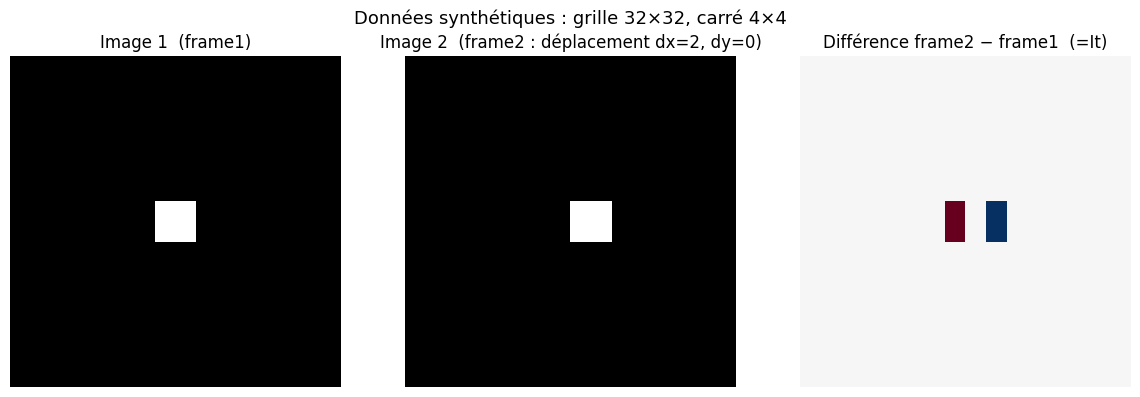

Taille des images  : 32×32 = 1024 pixels
Ix : min=-0.250, max=0.250
It : min=-1.000, max=1.000

Vérité terrain : u = 2 px/frame,  v = 0 px/frame  (sur le carré)


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# Données synthétiques : carré 4×4 qui se déplace sur une grille 32×32
# ─────────────────────────────────────────────────────────────────────────────

N = 32                        # taille de la grille (N × N pixels)

# ── Image 1 : fond noir, carré blanc 4×4 centré en (14, 14) ──────────────────
frame1 = np.zeros((N, N))
frame1[14:18, 14:18] = 1.0    # carré de 1 aux lignes 14-17, colonnes 14-17

# ── Image 2 : même carré déplacé de dx=2 pixels vers la droite ───────────────
dx, dy = 2, 0                 # déplacement connu (vérité terrain)
frame2 = np.zeros((N, N))
frame2[14+dy : 18+dy, 14+dx : 18+dx] = 1.0

# ── Visualisation ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(frame1, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
axes[0].set_title("Image 1  (frame1)")
axes[0].axis('off')

axes[1].imshow(frame2, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
axes[1].set_title(f"Image 2  (frame2 : déplacement dx={dx}, dy={dy})")
axes[1].axis('off')

axes[2].imshow(frame2 - frame1, cmap='RdBu', vmin=-1, vmax=1, interpolation='nearest')
axes[2].set_title("Différence frame2 − frame1  (=It)")
axes[2].axis('off')

plt.suptitle(f"Données synthétiques : grille {N}×{N}, carré 4×4", fontsize=13)
plt.tight_layout()
plt.show()

# ── Calcul des gradients sur ces données synthétiques ────────────────────────
Ix_syn, Iy_syn, It_syn = compute_gradients(frame1, frame2)

print(f"Taille des images  : {N}×{N} = {N*N} pixels")
print(f"Ix : min={Ix_syn.min():.3f}, max={Ix_syn.max():.3f}")
print(f"It : min={It_syn.min():.3f}, max={It_syn.max():.3f}")
print(f"\nVérité terrain : u = {dx} px/frame,  v = {dy} px/frame  (sur le carré)")

## Résolution directe par équations normales

### Questions préliminaires sur les dimensions

Avant de coder, répondez aux questions suivantes (remplacez les `???`) :

**Q1.** Pour une image $N \times N$ avec $N = 32$, combien y a-t-il de pixels $n$ ?

$$n = N \times N = 32 \times 32 = 1024$$

**Q2.** Le vecteur d'inconnues est $\mathbf{x} = \begin{pmatrix} U \\ V \end{pmatrix}$. Quelle est sa taille ?

$$\dim(\mathbf{x}) = 2n = 2048$$

**Q3.** Quelle est la taille de la matrice $A$ ?

$$A \in \mathbb{R}^{1024 \times 2048}$$

**Q4.** Quelle est la taille de la matrice de régularisation $L$ ?

$$L \in \mathbb{R}^{2048 \times 2048}$$

**Q5.** La matrice du système normal $M = A^\top A + \alpha L^\top L$ est de taille $2n \times 2n$. Pour $N=32$, donnez sa taille et estimez la mémoire nécessaire si elle était stockée dense (en supposant des `float64` = 8 octets) :

$$M \in \mathbb{R}^{2048 \times 2048}, \quad \text{mémoire dense} \approx \frac{33 554 432}{1000000} \text{ Mo} \approx 33.6 \text{ Mo}$$

> **Réponse attendue :** $n = 1024$, $2n = 2048$, $M$ de taille $2048 \times 2048$. Stockage dense : $\approx 32$ Mo. C'est faisable ici, mais pour une image $512 \times 512$ cela ferait $\approx 32$ **Go** — d'où l'intérêt du stockage **creux** (*sparse*).

**Q6.** Combien d'entrées non nulles (*nnz*) attend-on dans $M$ ? (Hint : $A^\top A$ est plein sur les diagonales, $L^\top L$ est sparse à 5 diagonales. Estimez l'ordre de grandeur.)

---

### Implémentation

─── Dimensions ──────────────────────────────────────────
  n    = N×N        = 1024   pixels
  2n   = 2×N×N      = 2048  inconnues [U ; V]
  A    ∈ R^(1024 × 2048)
  L    ∈ R^(2048 × 2048)
  b    ∈ R^(1024,)

  M    ∈ R^(2048 × 2048)  —  nnz = 25376
  rhs  ∈ R^(2048,)
  Mémoire dense ≈ 33.6 Mo  (sparse nnz/n² = 0.6 %)



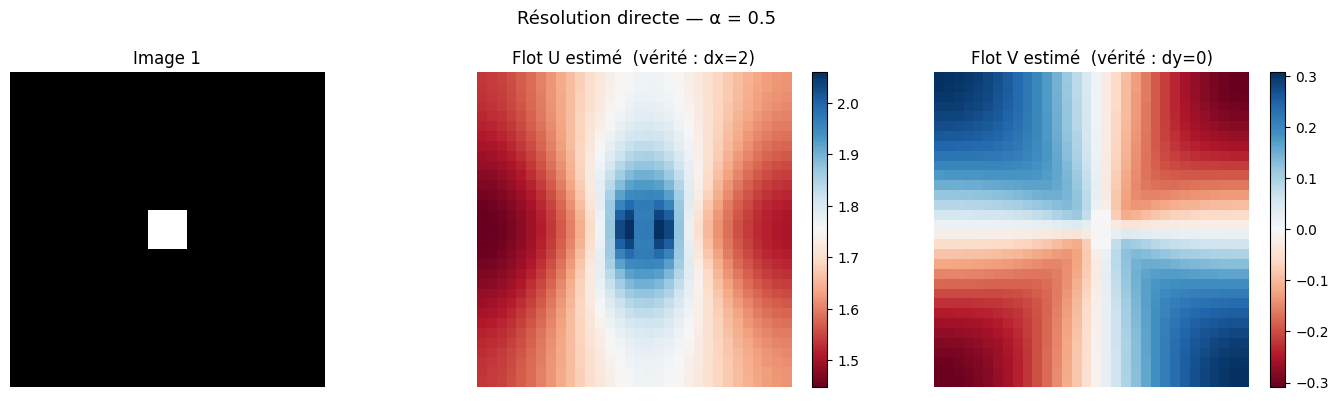

Erreur moyenne |U - dx| sur le carré : 0.0320
Erreur moyenne |V - dy| sur le carré : 0.0335


In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# Résolution directe : argmin_x ||Ax - b||² + α ||Lx||²
# ─────────────────────────────────────────────────────────────────────────────

alpha_dir = 0.5        # paramètre de régularisation (à faire varier !)

# ── Étape 1 : construire les matrices A et L ──────────────────────────────────
# On travaille sur les données synthétiques (frame1, frame2) de taille N×N=32×32.

A_dir = build_A(Ix_syn, Iy_syn)     # (n, 2n)
L_dir = build_L(N, N)               # (2n, 2n)
b_dir = -It_syn.ravel()             # (n,)   second membre

n_dir  = N * N
print("─── Dimensions ──────────────────────────────────────────")
print(f"  n    = N×N        = {n_dir}   pixels")
print(f"  2n   = 2×N×N      = {2*n_dir}  inconnues [U ; V]")
print(f"  A    ∈ R^({A_dir.shape[0]} × {A_dir.shape[1]})")
print(f"  L    ∈ R^({L_dir.shape[0]} × {L_dir.shape[1]})")
print(f"  b    ∈ R^{b_dir.shape}")
print()

# ── Étape 2 : former le système normal M x = rhs ─────────────────────────────
#   M   = A^T A + α L^T L    ∈ R^{2n × 2n}
#   rhs = A^T b              ∈ R^{2n}
#
#   Note : L^T L = L^T L.  Pour le laplacien discret symétrique L_Δ,
#          L_Δ^T = L_Δ  donc  L^T L = L^2  (carré de L).
#          On peut aussi écrire alpha * L^T @ L = alpha * L @ L.

M   = A_dir.T @ A_dir + alpha_dir * (L_dir.T @ L_dir)
rhs = A_dir.T @ b_dir

# ── Vérification des dimensions avant de résoudre ────────────────────────────
print(f"  M    ∈ R^({M.shape[0]} × {M.shape[1]})  —  nnz = {M.nnz}")
print(f"  rhs  ∈ R^{rhs.shape}")
mem_dense = M.shape[0]**2 * 8 / 1e6
print(f"  Mémoire dense ≈ {mem_dense:.1f} Mo  (sparse nnz/n² = {M.nnz / M.shape[0]**2 * 100:.1f} %)")
print()

# ── Étape 3 : résoudre le système linéaire ────────────────────────────────────
#   Option A — résolution directe (creuse) :
#       x_sol = spla.spsolve(M, rhs)
#
#   Option B — gradient conjugué (plus économique en mémoire) :
#       x_sol, info = spla.cg(M, rhs, tol=1e-8)
#       print(f"  CG convergé : info = {info}")  # 0 = succès

x_sol  = spla.spsolve(M, rhs)
U_dir  = x_sol[:n_dir].reshape(N, N)
V_dir  = x_sol[n_dir:].reshape(N, N)

# ── Étape 4 : visualisation ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(frame1, cmap='gray', interpolation='nearest')
axes[0].set_title("Image 1")
axes[0].axis('off')

axes[1].imshow(U_dir, cmap='RdBu', interpolation='nearest')
axes[1].set_title(f"Flot U estimé  (vérité : dx={dx})")
plt.colorbar(axes[1].images[0], ax=axes[1], fraction=0.046)
axes[1].axis('off')

axes[2].imshow(V_dir, cmap='RdBu', interpolation='nearest')
axes[2].set_title(f"Flot V estimé  (vérité : dy={dy})")
plt.colorbar(axes[2].images[0], ax=axes[2], fraction=0.046)
axes[2].axis('off')

plt.suptitle(f"Résolution directe — α = {alpha_dir}", fontsize=13)
plt.tight_layout()
plt.show()

# Erreur par rapport à la vérité terrain (sur les pixels du carré)
mask = frame1 > 0.5
print(f"Erreur moyenne |U - dx| sur le carré : {np.abs(U_dir[mask] - dx).mean():.4f}")
print(f"Erreur moyenne |V - dy| sur le carré : {np.abs(V_dir[mask] - dy).mean():.4f}")


In [25]:
# ─────────────────────────────────────────────────────────
# Énergie, gradient et hessien de Horn-Schunck discrétisé
# ─────────────────────────────────────────────────────────

def energy(U, V, Ix, Iy, It, L, alpha):
    """
    Calcule la valeur de la fonctionnelle discrétisée :

        E(U, V) = ||Ix*U + Iy*V + It||² + α (U' L U + V' L V)

    Paramètres
    ----------
    U, V  : np.ndarray 1-D de taille n (flot vectorisé)
    Ix, Iy, It : np.ndarray 1-D de taille n (gradients vectorisés)
    L     : sparse.csr_matrix (n, n)  laplacien discret
    alpha : float  paramètre de régularisation

    Retourne
    --------
    float
    """
    residual = Ix * U + Iy * V + It          # vecteur de taille n
    terme_data = np.dot(residual, residual)
    terme_reg  = U @ (L @ U) + V @ (L @ V)
    return terme_data + alpha * terme_reg


def gradient_E(U, V, Ix, Iy, It, L, alpha):
    """
    Calcule le gradient de E par rapport à (U, V).

        ∇_U E = 2 Ix * (Ix*U + Iy*V + It) + 2α L U
        ∇_V E = 2 Iy * (Ix*U + Iy*V + It) + 2α L V

    Retourne
    --------
    gU, gV : np.ndarray 1-D de taille n
    """
    residual = Ix * U + Iy * V + It
    gU = 2 * Ix * residual + 2 * alpha * (L @ U)
    gV = 2 * Iy * residual + 2 * alpha * (L @ V)
    return gU, gV


def hessian_E(Ix, Iy, L, alpha) -> sparse.csr_matrix:
    """
    Construit le hessien constant H ∈ R^{2n × 2n} :

        H = 2 * [[diag(Ix²) + αL,  diag(Ix*Iy)      ],
                  [diag(Ix*Iy),      diag(Iy²) + αL  ]]

    Retourne
    --------
    H : sparse.csr_matrix de taille (2n, 2n)
    """
    n = len(Ix)
    A2   = sparse.diags(Ix**2, format='csr')
    B2   = sparse.diags(Iy**2, format='csr')
    AB   = sparse.diags(Ix * Iy, format='csr')

    bloc_UU = A2 + alpha * L
    bloc_VV = B2 + alpha * L
    bloc_UV = AB
    H = 2 * sparse.bmat([[bloc_UU, bloc_UV],
                         [bloc_UV, bloc_VV]], format='csr')
    return H


# ── Vérification du gradient par différences finies ──────
def check_gradient(H_img, W_img, alpha=1.0, eps=1e-5):
    """Vérifie ∇E par rapport finie (test de cohérence)."""
    n   = H_img * W_img
    Ix_ = np.random.randn(n)
    Iy_ = np.random.randn(n)
    It_ = np.random.randn(n)
    L_  = build_laplacian(H_img, W_img)
    U0, V0 = np.random.randn(n), np.random.randn(n)
    dU, dV = np.random.randn(n), np.random.randn(n)

    E0       = energy(U0, V0, Ix_, Iy_, It_, L_, alpha)
    gU, gV   = gradient_E(U0, V0, Ix_, Iy_, It_, L_, alpha)
    grad_dir = gU @ dU + gV @ dV                          # dérivée directionnelle

    E_plus   = energy(U0 + eps*dU, V0 + eps*dV, Ix_, Iy_, It_, L_, alpha)
    fd_dir   = (E_plus - E0) / eps

    print(f"Dérivée directionnelle (gradient) : {grad_dir:.6f}")
    print(f"Différence finie                  : {fd_dir:.6f}")
    print(f"Erreur relative                   : {abs(grad_dir - fd_dir)/max(abs(fd_dir),1e-10):.2e}")

check_gradient(H, W)   


Dérivée directionnelle (gradient) : 168.215409
Différence finie                  : 168.607065
Erreur relative                   : 2.32e-03


## Descente de gradient à pas fixe

La mise à jour est :
$$X^{(k+1)} = X^{(k)} - \rho\, \nabla E(X^{(k)})$$

Pour garantir la convergence, il faut $\rho < \dfrac{2}{\lambda_{\max}(H)}$ (condition de Lipschitz). Pour $E$ quadratique, le taux de convergence est géométrique de raison $\left|1 - \rho\,\lambda_{\min}\right|$.

In [26]:
def gradient_descent_fixed(Ix, Iy, It, L, alpha, rho,
                            n_iter=500, tol=1e-6):
    """
    Descente de gradient à pas fixe ρ pour minimiser E(U, V).

    Algorithme
    ----------
    Initialisation : U⁰ = 0, V⁰ = 0
    Pour k = 0, 1, 2, ... :
        gU, gV  ← ∇E(Uᵏ, Vᵏ)
        Uᵏ⁺¹   ← Uᵏ - ρ · gU
        Vᵏ⁺¹   ← Vᵏ - ρ · gV
        si ‖(gU, gV)‖ < tol : arrêt

    Condition de convergence : ρ < 1 / λ_max(H/2)
    (pour E quadratique, λ_max(H) = 2*(‖Ix‖²_∞ + ‖Iy‖²_∞ + α*λ_max(L)))

    Paramètres
    ----------
    rho    : float  pas de gradient (fixe)
    n_iter : int    nombre maximal d'itérations
    tol    : float  critère d'arrêt sur la norme du gradient

    Retourne
    --------
    U, V    : np.ndarray 2-D (H, W)  champ de flot estimé
    history : list  valeurs de E à chaque itération
    """
    H_img = Ix.shape[0]
    W_img = Ix.shape[1]
    n     = H_img * W_img

    Ix_f, Iy_f, It_f = Ix.ravel(), Iy.ravel(), It.ravel()
    U = np.zeros(n)
    V = np.zeros(n)
    history = []

    for k in range(n_iter):
        gU, gV = gradient_E(U, V, Ix_f, Iy_f, It_f, L, alpha)

        U = U - rho * gU
        V = V - rho * gV

        E_k = energy(U, V, Ix_f, Iy_f, It_f, L, alpha)
        history.append(E_k)

        norm_g = np.sqrt(np.dot(gU, gU) + np.dot(gV, gV))
        if norm_g < tol:
            print(f"[GD fixe] Convergé en {k+1} itérations  (‖∇E‖ = {norm_g:.2e})")
            break
    else:
        print(f"[GD fixe] Arrêt après {n_iter} itérations  (‖∇E‖ = {norm_g:.2e})")

    return U.reshape(H_img, W_img), V.reshape(H_img, W_img), history


## Descente de gradient à pas optimal (recherche de ligne exacte)

Pour une fonction **quadratique** $E$, le pas optimal le long de la direction $d^{(k)} = -\nabla E(X^{(k)})$ est obtenu analytiquement en minimisant $\varphi(\rho) = E(X^{(k)} - \rho\,d^{(k)})$ :

$$\rho^*_k = \frac{\|\nabla E^{(k)}\|^2}{\nabla E^{(k)\top} H\, \nabla E^{(k)}}$$

Le produit $H\,g$ (avec $g = \nabla E$) s'évalue **sans former $H$** grâce aux formules :

$$[Hg]_U = 2\bigl(I_x \cdot (I_x g_U + I_y g_V) + \alpha L g_U\bigr)$$
$$[Hg]_V = 2\bigl(I_y \cdot (I_x g_U + I_y g_V) + \alpha L g_V\bigr)$$

Le dénominateur vaut alors $g^\top H g = g_U^\top [Hg]_U + g_V^\top [Hg]_V$.

In [27]:
def _hessian_times_vec(gU, gV, Ix, Iy, L, alpha):
    """
    Calcule le produit H·g sans former H explicitement :
        [Hg]_U = 2 ( Ix*(Ix*gU + Iy*gV) + α L gU )
        [Hg]_V = 2 ( Iy*(Ix*gU + Iy*gV) + α L gV )

    Utile pour le calcul du pas optimal et pour la méthode de Newton
    (direction = -H⁻¹ ∇E, résolu par conjugué gradient ou spsolve).
    """
    cross = Ix * gU + Iy * gV
    HgU = 2 * (Ix * cross + alpha * L @ gU)
    HgV = 2 * (Iy * cross + alpha * L @ gV)
    return HgU, HgV


def gradient_descent_optimal(Ix, Iy, It, L, alpha,
                              n_iter=200, tol=1e-6):
    """
    Descente de gradient à pas optimal (recherche exacte sur droite).

    Algorithme
    ----------
    Pour k = 0, 1, 2, ... :
        gU, gV  ← ∇E(Uᵏ, Vᵏ)
        num     ← ‖gU‖² + ‖gV‖²                           ← norme² du gradient
        HgU, HgV ← H · (gU, gV)   (via _hessian_times_vec)
        den     ← gU·HgU + gV·HgV                          ← g⊤Hg
        ρ*      ← num / den
        Uᵏ⁺¹   ← Uᵏ - ρ* · gU
        Vᵏ⁺¹   ← Vᵏ - ρ* · gV

    Retourne
    --------
    U, V    : np.ndarray 2-D (H, W)
    history : list  valeurs de E à chaque itération
    """
    H_img = Ix.shape[0]
    W_img = Ix.shape[1]
    n     = H_img * W_img

    Ix_f, Iy_f, It_f = Ix.ravel(), Iy.ravel(), It.ravel()
    U = np.zeros(n)
    V = np.zeros(n)
    history = []

    for k in range(n_iter):
        gU, gV = gradient_E(U, V, Ix_f, Iy_f, It_f, L, alpha)

        num = np.dot(gU, gU) + np.dot(gV, gV)
        if np.sqrt(num) < tol:
            print(f"[GD optimal] Convergé en {k+1} itérations")
            break

        HgU, HgV = _hessian_times_vec(gU, gV, Ix_f, Iy_f, L, alpha)
        den = np.dot(gU, HgU) + np.dot(gV, HgV)

        rho_opt = num / den
        U = U - rho_opt * gU
        V = V - rho_opt * gV

        history.append(energy(U, V, Ix_f, Iy_f, It_f, L, alpha))
    else:
        norm_g = np.sqrt(np.dot(gU, gU) + np.dot(gV, gV))
        print(f"[GD optimal] Arrêt après {n_iter} itérations  (‖∇E‖ = {norm_g:.2e})")

    return U.reshape(H_img, W_img), V.reshape(H_img, W_img), history


## Méthode de Newton

La méthode de Newton calcule la **direction de Newton** $d^{(k)}$ en résolvant le système linéaire :
$$H\, d^{(k)} = -\nabla E(X^{(k)})$$

puis effectue la mise à jour $X^{(k+1)} = X^{(k)} + d^{(k)}$.

Puisque $E$ est **quadratique**, $H$ est constant et Newton converge en **une seule itération** (le minimum exact). En pratique, cela revient à résoudre le système linéaire sparse $2n \times 2n$ :

$$\begin{pmatrix} A^2 + \alpha L & AB \\ AB & B^2 + \alpha L \end{pmatrix} \begin{pmatrix} U \\ V \end{pmatrix} = -\begin{pmatrix} A\,c \\ B\,c \end{pmatrix}$$

avec `scipy.sparse.linalg.spsolve` (résolution directe) ou `spla.cg` (gradient conjugué).

In [28]:
def newton_method(Ix, Iy, It, L, alpha, use_cg=False):
    """
    Méthode de Newton pour minimiser E(U, V).

    Pour une fonctionnelle quadratique, Newton converge en 1 itération en
    résolvant exactement le système linéaire H X = -∇E(0) où :

        H = 2 * [[diag(Ix²) + αL,  diag(Ix·Iy)      ],
                  [diag(Ix·Iy),      diag(Iy²) + αL  ]]

        -∇E(0) = -2 * [Ix · It,
                        Iy · It]

    Paramètres
    ----------
    use_cg : bool  si True, utilise le gradient conjugué (spla.cg) plutôt
                   que la factorisation directe (spla.spsolve) — recommandé
                   pour de très grandes images.

    Retourne
    --------
    U, V    : np.ndarray 2-D (H, W)
    history : list  [E(0), E(X*)]  (Newton en 1 pas pour E quadratique)
    """
    H_img = Ix.shape[0]
    W_img = Ix.shape[1]
    n     = H_img * W_img

    Ix_f, Iy_f, It_f = Ix.ravel(), Iy.ravel(), It.ravel()
    U0 = np.zeros(n)
    V0 = np.zeros(n)

    history = [energy(U0, V0, Ix_f, Iy_f, It_f, L, alpha)]

    # ── Construction du système H X = b ──────────────────────────────
    H_mat = hessian_E(Ix_f, Iy_f, L, alpha)

    # ── Construire le membre de droite b = -∇E(0)

    grad_U_E0, grad_V_E0 = 2 * Ix_f * It_f, 2 * Iy_f * It_f  #(car U=V=0)
    b = -np.concatenate([grad_U_E0, grad_V_E0])

    # ── Résolution ───────────────────────────────────────────────────
    if use_cg:
        X_sol, info = spla.cg(H_mat, b, rtol=1e-10)
        if info != 0:
            print(f"[Newton] Attention : CG info = {info}")
    else:
        X_sol = spla.spsolve(H_mat, b)

    U = X_sol[:n]
    V = X_sol[n:]

    history.append(energy(U, V, Ix_f, Iy_f, It_f, L, alpha))
    print(f"[Newton] E(0) = {history[0]:.4f}  →  E* = {history[1]:.4f}")
    return U.reshape(H_img, W_img), V.reshape(H_img, W_img), history


## Comparaison des méthodes et visualisation

[GD fixe] Arrêt après 300 itérations  (‖∇E‖ = 7.67e+00)
[GD optimal] Arrêt après 300 itérations  (‖∇E‖ = 1.75e-01)
[Newton] E(0) = 656.4005  →  E* = 639.3115


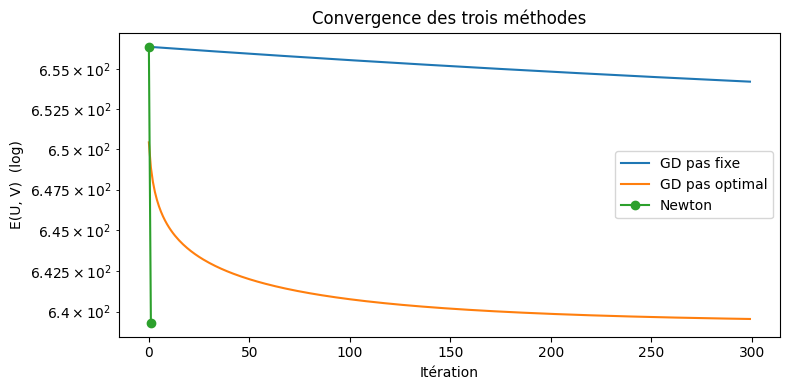

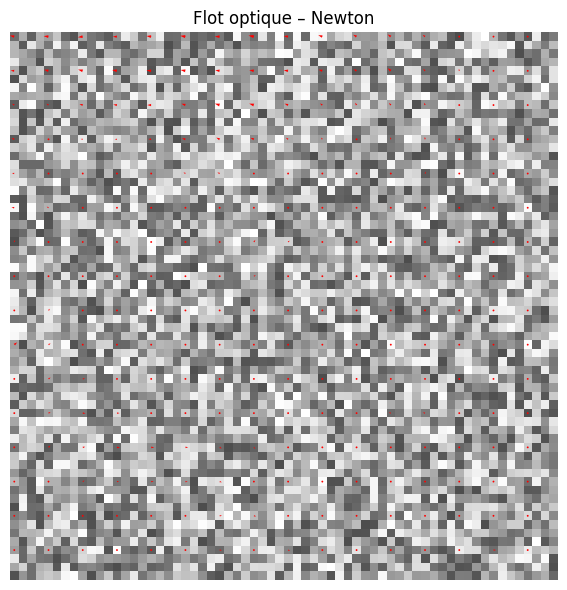

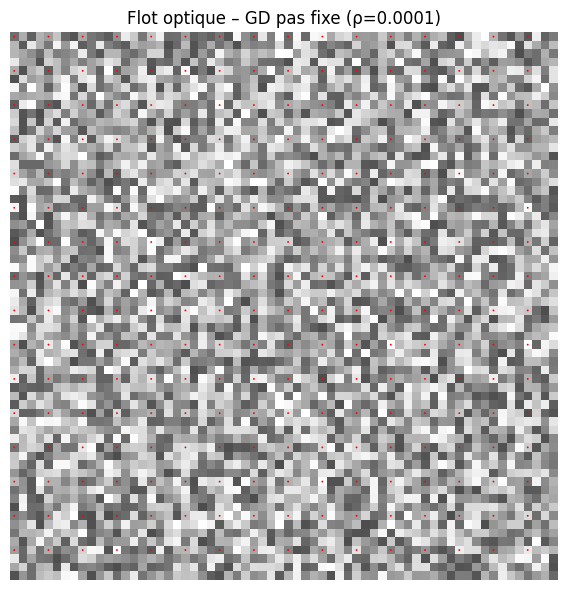

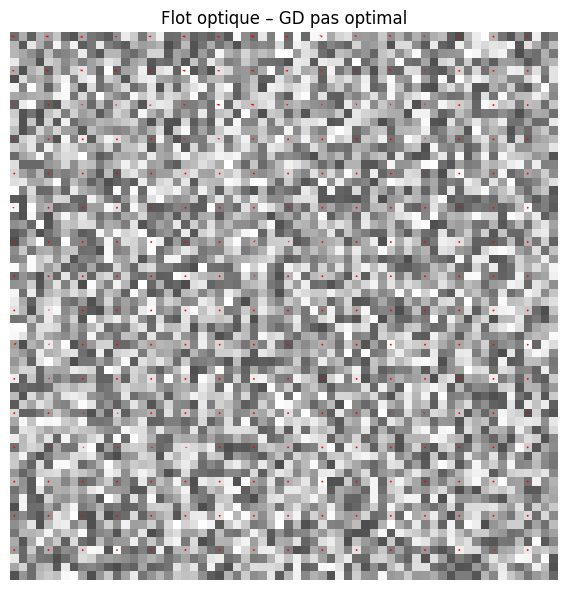

In [29]:
# ─────────────────────────────────────────────────────────
# Paramètres de l'expérience
# ─────────────────────────────────────────────────────────
alpha  = 1.0       # régularisation Horn-Schunck
rho    = 1e-4      # pas fixe (à adapter selon λ_max(H))
n_iter = 300       # iterations max pour les méthodes itératives

# ─────────────────────────────────────────────────────────
# Lancement des trois méthodes
# ─────────────────────────────────────────────────────────
U_fix,  V_fix,  hist_fix  = gradient_descent_fixed(Ix, Iy, It, L, alpha,
                                                    rho=rho, n_iter=n_iter)
U_opt,  V_opt,  hist_opt  = gradient_descent_optimal(Ix, Iy, It, L, alpha,
                                                      n_iter=n_iter)
U_newt, V_newt, hist_newt = newton_method(Ix, Iy, It, L, alpha)

# ─────────────────────────────────────────────────────────
# Courbes de convergence
# ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(hist_fix,  label="GD pas fixe")
ax.semilogy(hist_opt,  label="GD pas optimal")
ax.semilogy(hist_newt, marker='o', label="Newton")
ax.set_xlabel("Itération")
ax.set_ylabel("E(U, V)  (log)")
ax.set_title("Convergence des trois méthodes")
ax.legend()
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────
# Visualisation du champ de flot (Newton comme référence)
# ─────────────────────────────────────────────────────────
def plot_flow(U, V, img, title="Flot optique", step=4):
    """Affiche le champ de déplacement (U,V) en quiver sur l'image."""
    H_i, W_i = U.shape
    Y, X = np.mgrid[0:H_i:step, 0:W_i:step]
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(img, cmap='gray', alpha=0.7)
    ax.quiver(X, Y, U[::step, ::step], -V[::step, ::step],
              color='red', scale=1, scale_units='xy', angles='xy')
    ax.set_title(title)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

plot_flow(U_newt, V_newt, img1, title="Flot optique – Newton")
plot_flow(U_fix,  V_fix,  img1, title=f"Flot optique – GD pas fixe (ρ={rho})")
plot_flow(U_opt,  V_opt,  img1, title="Flot optique – GD pas optimal")

## Influence du paramètre régularisation $\alpha$


On souhaite étudier l’impact du paramètre de régularisation $\alpha$ dans la minimisation de l’énergie $E$, en résolvant les équations d’Euler-Lagrange associées à l’aide d’une méthode de descente de gradient à pas optimal, afin d'éviter de devoir à conditionner $\rho$ pour garantir la convergence.

On pose $E(U,V) = E_{data}(U,V) + \alpha E_{reg}(U,V)$

avec $E_{data}(U,V) =  \|AU + BV + I_t\|^2$ et $E_{reg}(U,V) = \alpha\,(U^\top L_\Delta U + V^\top L_\Delta V)$

À l'aide d'un graphique, on regarde les variations de $E_{data}$ et de $_{Ereg}$ en fonction des valeurs de $\alpha$

[GD optimal] Convergé en 2 itérations
[GD optimal] Convergé en 2 itérations
[GD optimal] Convergé en 2 itérations
[GD optimal] Convergé en 2 itérations
[GD optimal] Convergé en 2 itérations
[GD optimal] Convergé en 2 itérations
[GD optimal] Convergé en 3 itérations
[GD optimal] Convergé en 3 itérations
[GD optimal] Convergé en 5 itérations
[GD optimal] Convergé en 9 itérations
[GD optimal] Convergé en 11 itérations
[GD optimal] Convergé en 13 itérations
[GD optimal] Convergé en 13 itérations
[GD optimal] Convergé en 13 itérations
[GD optimal] Convergé en 13 itérations


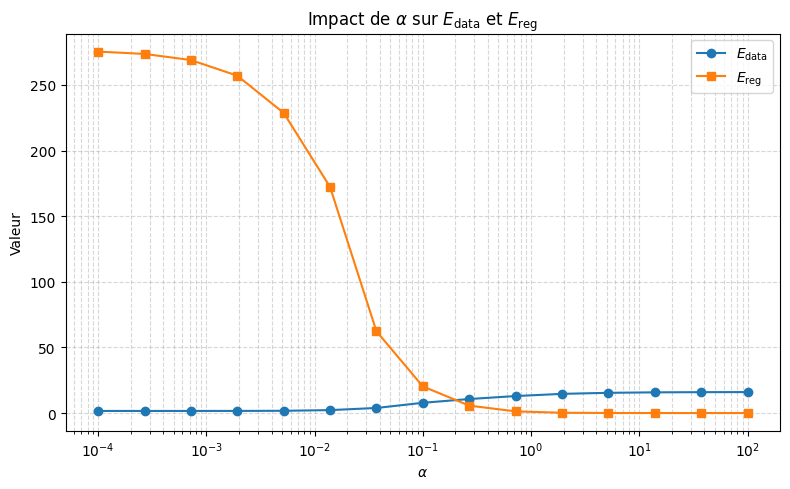

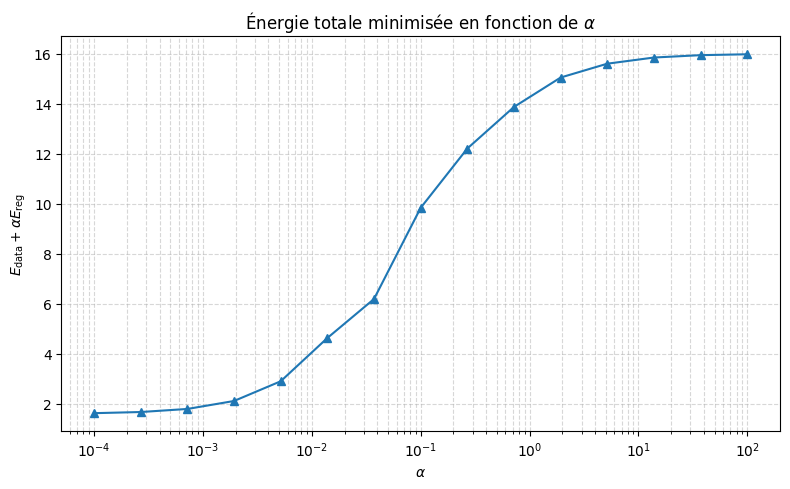

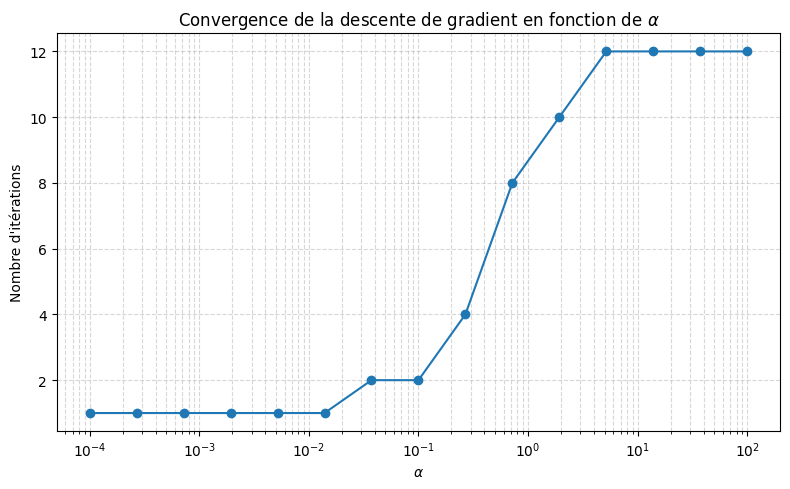

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# Données synthétiques : carré 4×4 qui se déplace sur une grille 32×32
# ─────────────────────────────────────────────────────────────────────────────

N = 32

frame1 = np.zeros((N, N))
frame1[14:18, 14:18] = 1.0

dx, dy = 2, 0
frame2 = np.zeros((N, N))
frame2[14+dy:18+dy, 14+dx:18+dx] = 1.0

Ix_syn, Iy_syn, It_syn = compute_gradients(frame1, frame2)
L_syn = build_laplacian(N, N)


# Fonctions pour séparer Edata et Ereg

def energy_data(U, V, Ix, Iy, It):
    residual = Ix * U + Iy * V + It
    return np.dot(residual, residual)

def energy_reg(U, V, L):
    return U @ (L @ U) + V @ (L @ V)

# Étude de l'impact de alpha

alphas = np.logspace(-4, 2, 15)   #de 10^-4 à 10^2
Edata_vals = []
Ereg_vals  = []
Etot_vals  = []
n_iters_vals = []

mask = frame1 > 0.5

for alpha in alphas:
    U, V, hist = gradient_descent_optimal(Ix_syn, Iy_syn, It_syn, L_syn, alpha,n_iter=500, tol=1)

    U_f = U.ravel()
    V_f = V.ravel()
    Ix_f   = Ix_syn.ravel()
    Iy_f   = Iy_syn.ravel()
    It_f   = It_syn.ravel()

    Edata = energy_data(U_f, V_f, Ix_f, Iy_f, It_f)
    Ereg  = energy_reg(U_f, V_f, L_syn)
    Etot  = Edata + alpha * Ereg

    Edata_vals.append(Edata)
    Ereg_vals.append(Ereg)
    Etot_vals.append(Etot)
    n_iters_vals.append(len(hist))

# conversion en arrays
Edata_vals = np.array(Edata_vals)
Ereg_vals  = np.array(Ereg_vals)
Etot_vals  = np.array(Etot_vals)
n_iters_vals = np.array(n_iters_vals)


# Tracé principal : Edata et Ereg en fonction de alpha

plt.figure(figsize=(8, 5))
plt.semilogx(alphas, Edata_vals, marker='o', label=r"$E_{\mathrm{data}}$")
plt.semilogx(alphas, Ereg_vals,  marker='s', label=r"$E_{\mathrm{reg}}$")
plt.xlabel(r"$\alpha$")
plt.ylabel("Valeur")
plt.title(r"Impact de $\alpha$ sur $E_{\mathrm{data}}$ et $E_{\mathrm{reg}}$")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


# Tracé optionnel : énergie totale

plt.figure(figsize=(8, 5))
plt.semilogx(alphas, Etot_vals, marker='^')
plt.xlabel(r"$\alpha$")
plt.ylabel(r"$E_{\mathrm{data}} + \alpha E_{\mathrm{reg}}$")
plt.title(r"Énergie totale minimisée en fonction de $\alpha$")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.semilogx(alphas, n_iters_vals, marker='o')
plt.xlabel(r"$\alpha$")
plt.ylabel("Nombre d'itérations")
plt.title(r"Convergence de la descente de gradient en fonction de $\alpha$")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

On observe que lorsque $\alpha$ augmente, $E_{data}$ augmente légèrement, $E_{reg}$ diminue fortement. Cela traduit le fait que la régularisation est davantage pénalisée, ce qui conduit à des solutions plus lisses, au prix d'un bon ajustement aux données.

# Méthode Lucas-Kanade


In [31]:
def lucas_kanade_sparse(video_path, max_corners=100):
    """
    Flot optique sparse avec Lucas-Kanade.
    Suit des points d'intérêt entre frames successives.
    """
    cap = cv2.VideoCapture(video_path)

    # Paramètres pour la détection de coins
    feature_params = dict(
        maxCorners=max_corners,
        qualityLevel=0.3,
        minDistance=7,
        blockSize=7
    )

    # Paramètres Lucas-Kanade
    lk_params = dict(
        winSize=(15, 15),
        maxLevel=2,
        criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)
    )

    ret, old_frame = cap.read()
    old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)
    p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)

    trajectories = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Calcul du flot optique
        p1, status, err = cv2.calcOpticalFlowPyrLK(
            old_gray, frame_gray, p0, None, **lk_params
        )

        # Sélection des bons points
        if p1 is not None:
            good_new = p1[status == 1]
            good_old = p0[status == 1]

            # Stockage des déplacements
            for new, old in zip(good_new, good_old):
                trajectories.append({
                    'old': old.flatten(),
                    'new': new.flatten(),
                    'flow': (new - old).flatten()
                })

        old_gray = frame_gray.copy()
        p0 = good_new.reshape(-1, 1, 2)

    cap.release()
    return trajectories



def farneback_dense(frame1, frame2):
    """
    Flot optique dense avec méthode de Farneback.
    Retourne le champ de flot (u, v) pour chaque pixel.
    """
    gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

    flow = cv2.calcOpticalFlowFarneback(
        gray1, gray2, None,
        pyr_scale=0.5,  # facteur de réduction pyramide
        levels=3,       # nombre de niveaux
        winsize=15,     # taille fenêtre
        iterations=3,   # itérations par niveau
        poly_n=5,       # taille voisinage polynôme
        poly_sigma=1.2, # sigma du gaussien
        flags=0
    )

    # flow[:,:,0] = composante u (horizontale)
    # flow[:,:,1] = composante v (verticale)
    return flow

def visualize_flow(flow):
    """
    Visualise le flot optique en HSV (teinte=direction, saturation=magnitude).
    """
    magnitude, angle = cv2.cartToPolar(flow[:,:,0], flow[:,:,1])
    hsv = np.zeros((*flow.shape[:2], 3), dtype=np.uint8)
    hsv[..., 0] = angle * 180 / np.pi / 2  # Teinte
    hsv[..., 1] = 255                      # Saturation
    hsv[..., 2] = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)
    rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
    return rgb

In [32]:
cap = cv2.VideoCapture("20260412_191420.mp4")
print(f"La vidéo s'ouvre : {cap.isOpened()}  ")
print()

traj = lucas_kanade_sparse("20260412_191420.mp4")

La vidéo s'ouvre : True  



La méthode de Lucas–Kanade renvoie une liste de vecteurs de déplacement associés à des points d’intérêt. Pour chaque point, on dispose de sa position dans l’image précédente (old) et de sa position correspondante dans l’image suivante (new). Le vecteur de flot est défini par la différence entre ces deux positions. Un vecteur flot nul correspond à une absence de mouvement, tandis qu’un vecteur non nul indique un déplacement dont la direction et la norme traduisent respectivement la direction et l’amplitude du mouvement.


Commençons par comparer cette méthode avec la méthode d'Horn-Schunck pour deux frames.

In [ ]:
cap = cv2.VideoCapture("20260412_191420.mp4")

cap.set(cv2.CAP_PROP_POS_FRAMES, 30)  # aller à la frame 30 (à 1 seconde de la vidéo)

ret, frame1 = cap.read()
ret, frame2 = cap.read()

traj = lucas_kanade_sparse("20260412_191420.mp4")



## Partie vidéo

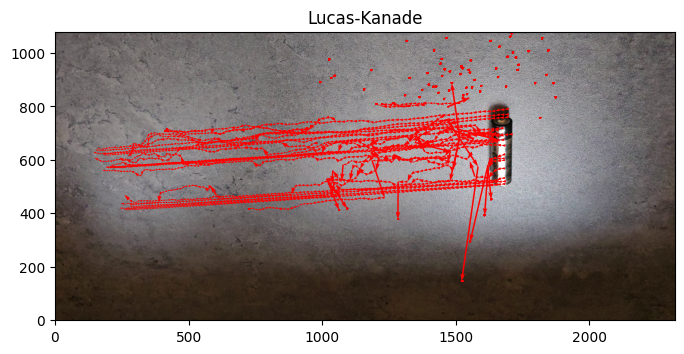

In [ ]:
traj = lucas_kanade_sparse("20260412_191420.mp4")
old_points = []
flots = []

for d in traj:
    old_points.append(d['old'])

for d in traj:
    flots.append(d['flow'])

old_points = np.array(old_points)
flots = np.array(flots)

cap = cv2.VideoCapture("20260412_191420.mp4")
ret, frame = cap.read()
cap.release()

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 6))
plt.imshow(frame_rgb)
plt.quiver(old_points[:, 0], old_points[:, 1],flots[:, 0], flots[:, 1],angles='xy', scale_units='xy', scale=1, color='red')
plt.title("Lucas-Kanade sparse")
plt.gca().invert_yaxis()
plt.show()